In [1]:
using PyPlot
using JLD2
using Statistics
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful
using Interpolations
using LsqFit
using MAT
using Images, ImageMorphology

In [2]:
function decay_atoms_indep(sat)
    return 1/2 .* 1 ./ (1 .+ 1 ./sat)
end

decay_atoms_indep (generic function with 1 method)

In [3]:
pathdir_stripe_90 = "Y:/StructuralPhaseTransition/2026/02/11/0001" # Stripes 90°

N = 30
λ = 421e-9
γ = 32.7e6 # In Hz
Γ = 2.02e8 # In Hz

ω0 = 2π*ustrip(c_0)/λ

Isat = Γ*ω0^2 / (12*π*ustrip(c_0)^2) # In photon/m^2/atom

mask_dilation = 11

size_pxl = 0.1966e-6; # New pxl size since 2025/12/31

### Load experimental data

In [4]:
# Stripe 90
@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" Imgs_atoms_crop Imgs_bkg_crop Imgs_dark_crop Amplitude_laser τ_exp
@load "Saved_exp_data/Intensity_integrated_mask_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" I_atoms_masked_ds I_bkg_masked_ds I_dark_masked_ds Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms
@load "Saved_exp_data/Nbr_atoms_per_mask_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" Nbr_atoms_per_mask;

### Fit the experimental saturation parameter

In [5]:
I_elec_measured = [0.1:0.1:1;]
P_measured = [0.004, 0.035, 0.15, 0.43, 0.9, 1.5, 2.1, 2.6, 3, 3.4] * 1e-3
w0 = 300.0750022524122e-6 # Fitted waist
sat_measured = 2 .* P_measured ./ (π*w0^2 * Isat * ustrip(ħ * ω0))
interp_linear = linear_interpolation(I_elec_measured, sat_measured);

In [6]:
linear(x, p) = p[1] .* x
p0 = [2.]
fit = curve_fit(linear, reshape(mean(I_bkg_masked_ds/Isat, dims=2), length(unique(Amplitude_laser))), interp_linear(unique(Amplitude_laser)), p0)
factor_sat = fit.param[1];

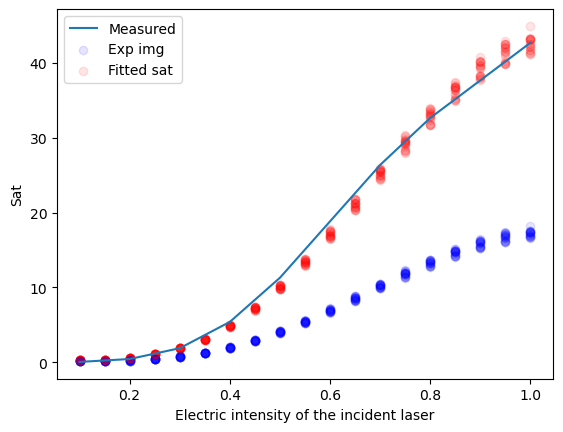

In [7]:
plot(I_elec_measured, sat_measured, label="Measured")

for i = 1:size(I_bkg_masked_ds)[1]
    for j = 1:size(I_bkg_masked_ds)[2]
        if I_bkg_masked_ds[i, j] > 0
            scatter(unique(Amplitude_laser)[i], I_bkg_masked_ds[i, j]/Isat, color="b", alpha=0.1)
            scatter(unique(Amplitude_laser)[i], I_bkg_masked_ds[i, j]/Isat * factor_sat, color="r", alpha=0.1)
        end
    end
end
legend(["Measured", "Exp img", "Fitted sat"])
xlabel("Electric intensity of the incident laser")
ylabel("Sat");

### For the simulations, gets the $I_{tot}$ per stripe, taking into account the nbr of atoms in each stripe

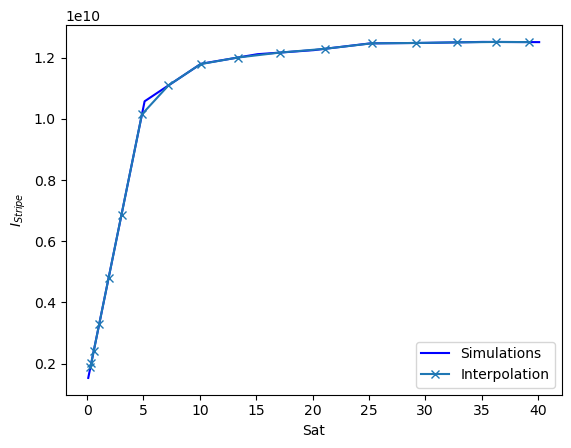

In [64]:
# Interpolate the simulations
@load "Solutions_sim/Itot_N_30_Sat_0.1to40.1_n0_53.12_decay_rate_up_down.jdl2"  sat sat_computed n_list Itot_stripe I_SE_SR_SS_stripe I_SR_SR_SS_stripe nbr_error_N

interp_linear_sim = linear_interpolation(sat_computed, reshape(Itot_stripe, length(Itot_stripe)))

idx_lb = 1
idx_hb = 17

close("all")
fig = subplot()

plot(sat_computed, Itot_stripe, label="Simulations", color="b")
plot(factor_sat * Mean_bkg[idx_lb:idx_hb]/Isat, [interp_linear_sim(factor_sat * bkg/Isat) for bkg in Mean_bkg[idx_lb:idx_hb]], label="Interpolation", marker="x")

legend()
xlabel("Sat")
ylabel(L"I_{Stripe}")

# pygui(true); show();
pygui(false);

In [72]:
# Compute the simulated intensity for each image
I_sim = zeros((idx_hb-idx_lb+1, size(I_bkg_masked_ds)[2])) # # lines = Saturation, # columns = repetitions
se = ones(Bool, mask_dilation, mask_dilation)

for i = idx_lb:idx_hb
    for j = 1:size(I_bkg_masked_ds)[2]
        matopen("Saved_masks/$((j-1)*size(I_bkg_masked_ds)[1]+i).mat") do file
            mask = read(file, "binaryMask")
            mask_dilated = dilate(mask, se)
            S_mask = length(mask_dilated[mask_dilated.>0]) * size_pxl^2
            if factor_sat*I_bkg_masked_ds[i, j]/Isat < sat_computed[end] # To avoid errors with interpolation out of data bounds
                I_sim[i-idx_lb+1, j] = (Nbr_atoms_per_mask[i, j]/(N*length(n_list)*S_mask)) * interp_linear_sim(factor_sat * I_bkg_masked_ds[i, j]/Isat)
            end
        end
    end
end

### Higher density simulations

In [73]:
# Read data without overwriting the other set of simulations
file = jldopen("Solutions_sim/Itot_N_30_Sat_0.1to40.1_n0_531.24_decay_rate_up_down.jdl2", "r")
sat_high_n, sat_computed_high_n, n_list_high_n, Itot_stripe_high_n, I_SE_SR_SS_stripe_high_n, I_SR_SR_SS_stripe_high_n, nbr_error_N_high_n = file["sat"], file["sat_computed"], file["n_list"], file["Itot_stripe"], file["I_SE_SR_SS_stripe"], file["I_SR_SR_SS_stripe"], file["nbr_error_N"]
close(file)

# Add the higher densities
file = jldopen("Solutions_sim/Itot_N_30_Sat_20.1to40.1_n0_531.24_decay_rate_up_down.jdl2", "r")
sat_high_n, sat_computed_high_n, n_list_high_n, Itot_stripe_high_n, I_SE_SR_SS_stripe_high_n, I_SR_SR_SS_stripe_high_n, nbr_error_N_high_n = vcat(sat_high_n, file["sat"]), vcat(sat_computed_high_n, file["sat_computed"]), vcat(n_list_high_n, file["n_list"]), vcat(Itot_stripe_high_n, file["Itot_stripe"]), vcat(I_SE_SR_SS_stripe_high_n, file["I_SE_SR_SS_stripe"]), vcat(I_SR_SR_SS_stripe_high_n, file["I_SE_SR_SS_stripe"]), vcat(nbr_error_N_high_n, ["nbr_error_N"])
close(file)

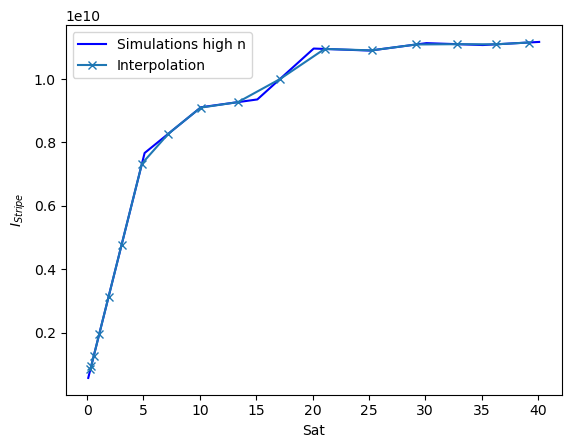

In [74]:
# Interpolate the simulations

interp_linear_sim_high_n = linear_interpolation(sat_computed_high_n, reshape(Itot_stripe_high_n, length(Itot_stripe_high_n)))

idx_lb = 1
idx_hb = 17

close("all")
fig = subplot()

plot(sat_computed_high_n, Itot_stripe_high_n, label="Simulations high n", color="b")
plot(factor_sat * Mean_bkg[idx_lb:idx_hb]/Isat, [interp_linear_sim_high_n(factor_sat * bkg/Isat) for bkg in Mean_bkg[idx_lb:idx_hb]], label="Interpolation", marker="x")

legend()
xlabel("Sat")
ylabel(L"I_{Stripe}")

# pygui(true); show();
pygui(false);

In [81]:
# Compute the simulated intensity for each image
I_sim_high_n = zeros((idx_hb-idx_lb+1, size(I_bkg_masked_ds)[2]))
se = ones(Bool, mask_dilation, mask_dilation)

for i = idx_lb:idx_hb
    for j = 1:size(I_bkg_masked_ds)[2]
        matopen("Saved_masks/$((j-1)*size(I_bkg_masked_ds)[1]+i).mat") do file
            mask = read(file, "binaryMask")
            mask_dilated = dilate(mask, se)
            S_mask = length(mask_dilated[mask_dilated.>0]) * size_pxl^2
            if factor_sat*I_bkg_masked_ds[i, j]/Isat < sat_computed[end] # To avoid errors with interpolation out of data bounds
                I_sim_high_n[i-idx_lb+1, j] = (Nbr_atoms_per_mask[i, j]/(N*length(n_list)*S_mask)) * interp_linear_sim_high_n(factor_sat * I_bkg_masked_ds[i, j]/Isat)
            end
        end
    end
end

### SE

In [76]:
# Compute the simulated intensity for each image
I_SE = zeros(size(I_bkg_masked_ds))

for i = 1:size(I_bkg_masked_ds)[1]
    for j = 1:size(I_bkg_masked_ds)[2]
        matopen("Saved_masks/$((j-1)*size(I_bkg_masked_ds)[1]+i).mat") do file
            mask = read(file, "binaryMask")
            mask_dilated = dilate(mask, se)
            S_mask = length(mask_dilated[mask_dilated.>0]) * size_pxl^2
            I_SE[i, j] += (Nbr_atoms_per_mask[i, j]/S_mask) * decay_atoms_indep(factor_sat * I_bkg_masked_ds[i, j]/Isat) * γ
        end
    end
end

### Plot as a function of Sat measured from the images bkg

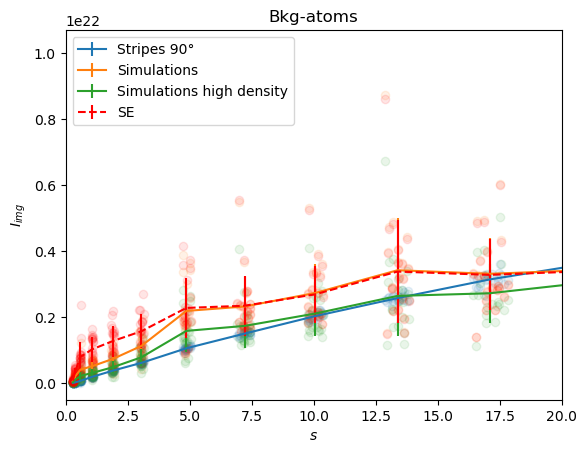

In [82]:
close("all")
fig = subplots()
title("Bkg-atoms")


# Stripes 90°
line_stripe_90, = errorbar(factor_sat * Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Stripes 90°")

for i = 1:size(I_atoms_masked_ds)[1]
    for j = 1:size(I_atoms_masked_ds)[2]
        scatter(factor_sat * I_bkg_masked_ds[i, j]/Isat, I_bkg_masked_ds[i, j]-I_atoms_masked_ds[i, j], color=line_stripe_90.get_color(), alpha = 0.1)
    end
end


# # Simulations
factor_sim_data = (1-0.16) # Amount of light that will not enter in the camera
line_sim, = errorbar(factor_sat * Mean_bkg[idx_lb:idx_hb]/Isat, reshape(factor_sim_data * mean(I_sim, dims=2), size(I_sim)[1]), yerr=reshape(factor_sim_data * std(I_sim, dims=2), size(I_sim)[1]), label="Simulations")

for i = 1:size(I_sim)[1]
    for j = 1:size(I_sim)[2]
        scatter(factor_sat * I_bkg_masked_ds[i+idx_lb-1, j]/Isat, factor_sim_data * I_sim[i, j], color=line_sim.get_color(), alpha = 0.1)
    end
end

# # Simulations high density
factor_sim_data = (1-0.16) # Amount of light that will not enter in the camera
line_sim_high_n, = errorbar(factor_sat * Mean_bkg[idx_lb:idx_hb]/Isat, reshape(factor_sim_data * mean(I_sim_high_n, dims=2), size(I_sim_high_n)[1]), yerr=reshape(factor_sim_data * std(I_sim_high_n, dims=2), size(I_sim_high_n)[1]), label="Simulations high density")

for i = 1:size(I_sim_high_n)[1]
    for j = 1:size(I_sim_high_n)[2]
        scatter(factor_sat * I_bkg_masked_ds[i+idx_lb-1, j]/Isat, factor_sim_data * I_sim_high_n[i, j], color=line_sim_high_n.get_color(), alpha = 0.1)
    end
end


# # SE
line_SE, = errorbar(factor_sat * Mean_bkg/Isat, reshape(factor_sim_data * mean(I_SE, dims=2), size(I_SE)[1]), yerr=reshape(factor_sim_data * std(I_SE, dims=2), size(I_SE)[1]), label="SE", color="r", linestyle="--")

for i = 1:size(I_SE)[1]
    for j = 1:size(I_SE)[2]
        scatter(factor_sat * I_bkg_masked_ds[i, j]/Isat, factor_sim_data * I_SE[i, j], color=line_SE.get_color(), alpha = 0.1)
    end
end


xlabel(L"s")
ylabel(L"I_{img}")

xlim(0, 20)

legend()

# pygui(true); show();
pygui(false);

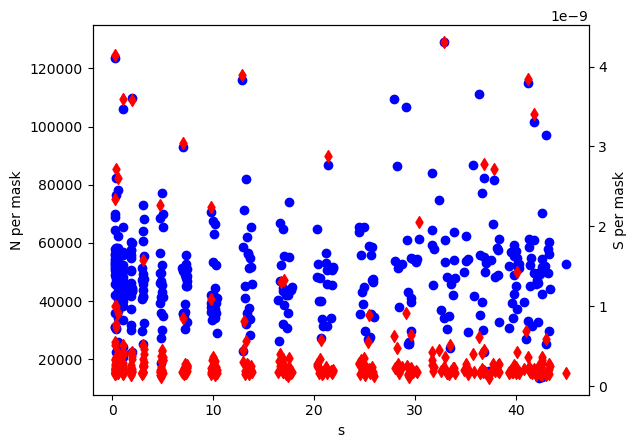

In [33]:
fig, ax1 = subplots()
ax2 = ax1.twinx()  

for i = 1:size(Nbr_atoms_per_mask)[1]
    for j = 1:size(Nbr_atoms_per_mask)[2]
        ax1.scatter(I_bkg_masked_ds[i, j]/Isat * factor_sat, Nbr_atoms_per_mask[i, j], color="b")
        matopen("Saved_masks/$((i-1)*size(I_bkg_masked_ds)[2]+j).mat") do file
            mask_dilated = dilate(read(file, "binaryMask"), se)
            S_mask = length(mask_dilated[mask_dilated.>0]) * size_pxl^2
            ax2.scatter(I_bkg_masked_ds[i, j]/Isat * factor_sat, S_mask, color="r", marker="d")
        end
    end
end

ax1.set_xlabel("s")
ax1.set_ylabel("N per mask")
ax2.set_ylabel("S per mask")


# pygui(true); show()
pygui(false);

### Weird constant surfaces

In [34]:
@load "Saved_exp_data/ODs_crop_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" ODs;

In [37]:
I_sim_high_n

17×20 Matrix{Float64}:
 3.24335e19  3.36582e19  6.62279e19  …  2.99123e20  3.73154e20  3.23957e19
 3.71209e19  1.13696e20  1.21353e20     3.59151e20  3.71131e19  3.73869e19
 1.02614e20  2.16246e20  2.1108e20      4.97214e19  6.93333e19  1.56986e20
 2.75557e20  3.43774e20  3.83798e20     1.36858e20  2.27659e20  2.35859e20
 4.81984e20  5.61094e20  6.78636e20     5.28167e20  8.68203e20  5.73954e20
 8.89773e20  9.51132e20  9.91934e20  …  9.12846e20  1.17378e21  8.71838e20
 1.39515e21  1.39216e21  1.85105e21     1.63622e21  1.74855e21  1.04498e21
 1.48948e21  1.64714e21  1.97375e21     2.10825e21  2.09921e21  1.52258e21
 1.65912e21  1.8576e21   2.0471e21      2.62055e21  2.65194e21  1.68374e21
 1.99211e21  2.11638e21  2.26428e21     3.04607e21  3.0643e21   1.96931e21
 2.16245e21  2.25363e21  2.5548e21   …  3.3847e21   3.65116e21  2.29939e21
 2.59142e21  2.64085e21  2.88222e21     3.7368e21   3.99728e21  2.54684e21
 2.65859e21  2.5997e21   3.12883e21     3.53515e21  4.27933e21  2.44589e21
 2

6.21520949956e-9


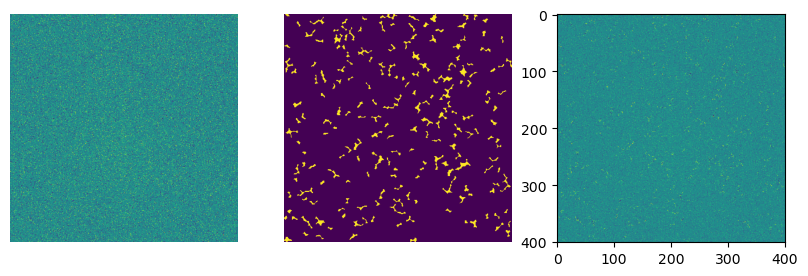

In [51]:
close("all")
fig, axs = subplots(1, 3, figsize=(10, 5))
i, j = 1, 4
idx = (j-1)*size(I_bkg_masked_ds)[1]+i


matopen("Saved_masks/$idx.mat") do file
    mask, xStart, yStart = read(file, "binaryMask")', read(file, "xStart")', read(file, "yStart")'
    S_mask = length(mask) * size_pxl^2
    println(S_mask)

    axs[1].imshow(ODs[idx, :, :])
    axs[2].imshow(mask)
    axs[3].imshow(ODs[idx, :, :][Int(xStart):size(mask)[1]+Int(xStart)-1, Int(yStart):size(mask)[2]+Int(yStart)-1] .* mask .+ ODs[idx, :, :][Int(xStart):size(mask)[1]+Int(xStart)-1, Int(yStart):size(mask)[2]+Int(yStart)-1])
end

axs[1].axis("off")
axs[2].axis("off")

pygui(false);